# Import

In [1]:
import cv2
import skimage.io
import skimage.metrics
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
print(cv2.__version__)

5.0.0


# Reading images

In [3]:
# For the experiment purpose, I will put the Google Drive paths directly.
Ker = cv2.imread("/content/drive/MyDrive/ML-OCT_project_datasets/OCT2017/train/DME/DME-1072015-2.jpeg",0)
ID = cv2.imread("/content/drive/MyDrive/ML-OCT_project_datasets/108503-V1/Diabetic-Retinopathy-Retinal-OCT-Images/OCTID_DR/DR1.jpeg",0)
DL = cv2.imread("/content/drive/MyDrive/ML-OCT_project_datasets/OCTDL Optical Coherence Tomography Dataset for Image-Based Deep Learning Methods/OCTDL/DME/dme_1057060_1.jpg",0)

#image chosen arbitrarily

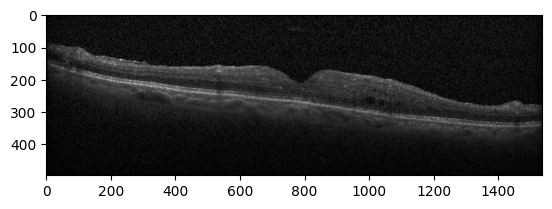

In [4]:
plt.imshow(Ker,cmap="gray")

# PSNR

In [5]:
#sum of all the denoising techniques:4x4 +4+4 +8 +2
psnrs = np.zeros((34,3))
denoise_techniques = []


images = [Ker, ID, DL]
for i in range(len(images)):
  #Gaussian
  kernel_sizes = [3,5,7,9]
  sigmas = [0.5,1.0,1.5,2.0]

  count = 0
  for k in kernel_sizes:
    for s in sigmas:
      #print("kernel {} sigma {}".format(k,s))

      Gaus = cv2.GaussianBlur(images[i],(k,k),s)

      psnr = cv2.PSNR(images[i], Gaus)
      #psnr_ski_ID = skimage.metrics.peak_signal_noise_ratio(ID, Gaus_ID)

      #print(psnr_ID)
      psnrs[count,i] = psnr
      count +=1
      if i==0:
        denoise_techniques.append("Gaussian {}x{} sigma {}".format(k,k,s))
  #Median
  kernel_sizes = [3,5,7,9]


  for k in kernel_sizes:
    med = cv2.medianBlur(images[i],k)
    psnr = cv2.PSNR(images[i],med)
    psnrs[count,i] = psnr
    count +=1

    if i ==0:
      denoise_techniques.append("Median {}x{}".format(k,k))
  #Mean
  kernel_sizes = [3,5,7,9]

  for k in kernel_sizes:
    mean = cv2.blur(images[i],(k,k))
    psnr = cv2.PSNR(images[i],mean)
    psnrs[count,i] = psnr
    count +=1

    if i ==0:
      denoise_techniques.append("Mean {}x{}".format(k,k))
  #Bilateral
  ds = [5,7]
  sigmas_color = [10,20]
  sigmas_space = [10,20]

  for d in ds:
    for sc in sigmas_color:
      for ss in sigmas_color:
        bilateral = cv2.bilateralFilter(images[i],d,sc,ss)
        psnr = cv2.PSNR(images[i],bilateral)
        psnrs[count,i] = psnr
        count+=1

        if i ==0:
          denoise_techniques.append("Bilateral d {} sigmaColor {} sigmaSpace{}".format(d,sc,ss))

  #Non local means
  hs = [10,20]

  for h in hs:
    nl =cv2.fastNlMeansDenoising(images[i],h) #search window and block size are default size? #should I vary them as well?
    psnr =cv2.PSNR(images[i],nl)
    psnrs[count,i] = psnr
    count+=1

    if i ==0:
      denoise_techniques.append("Non-local means h {}".format(h))



#print(psnrs)
#print(denoise_techniques)

# Plotting

In [6]:
datasets = ["Kermany","OCTID","OCTDL"]

"""
fig, ax = plt.subplots()
im = ax.imshow(psnrs)

ax.set_xticks(range(len(datasets)), labels=datasets, rotation =45)
ax.set_yticks(range(len(denoise_techniques)),labels=denoise_techniques)

for i in range(len(denoise_techniques)):
  for j in range(len(datasets)):
    text = ax.text(j,i,psnrs[i,j].round(1), ha="center", va="center", color = "w")

ax.set_title("PSNR")
fig.tight_layout()
plt.show()
"""

'\nfig, ax = plt.subplots()\nim = ax.imshow(psnrs)\n\nax.set_xticks(range(len(datasets)), labels=datasets, rotation =45)\nax.set_yticks(range(len(denoise_techniques)),labels=denoise_techniques)\n\nfor i in range(len(denoise_techniques)):\n  for j in range(len(datasets)):\n    text = ax.text(j,i,psnrs[i,j].round(1), ha="center", va="center", color = "w")\n\nax.set_title("PSNR")\nfig.tight_layout()\nplt.show()\n'

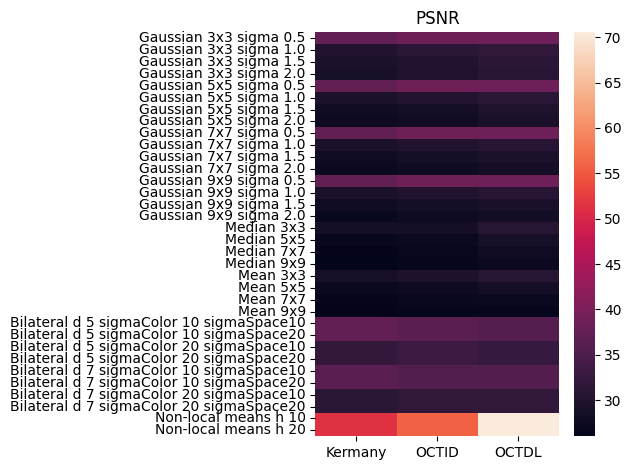

In [7]:
sns.heatmap(psnrs, xticklabels = datasets, yticklabels= denoise_techniques)
plt.title("PSNR")
plt.tight_layout()
plt.show()

# Adding noise

In [18]:
Ker=skimage.util.img_as_float(Ker)
ID=skimage.util.img_as_float(ID)
DL=skimage.util.img_as_float(DL)

In [19]:
Ker_speckle = skimage.util.random_noise(Ker, mode="speckle",mean = 0, var=1)
ID_speckle = skimage.util.random_noise(ID, mode="speckle",mean = 0, var=1)
DL_speckle = skimage.util.random_noise(DL, mode="speckle",mean = 0, var=1)

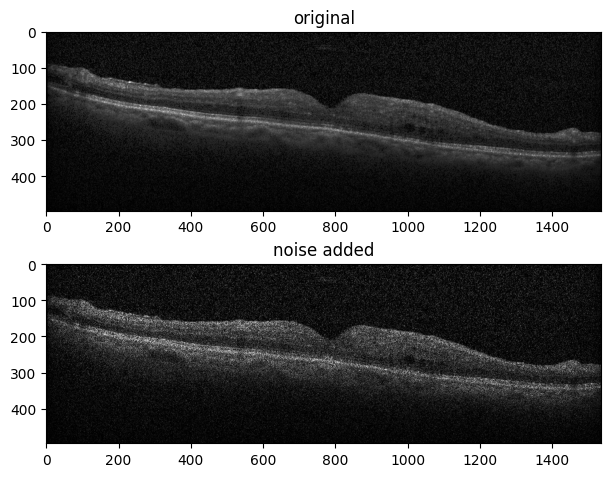

In [20]:
plt.subplot(211)
plt.imshow(Ker,cmap="gray")
plt.title("original")

plt.subplot(212)
plt.imshow(Ker_speckle,cmap="gray")
plt.title("noise added")

plt.tight_layout()
plt.show()

In [21]:
print(Ker_speckle.shape)
print(Ker.shape)

(496, 1536)
(496, 1536)


images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


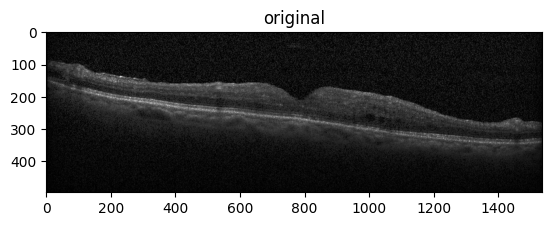

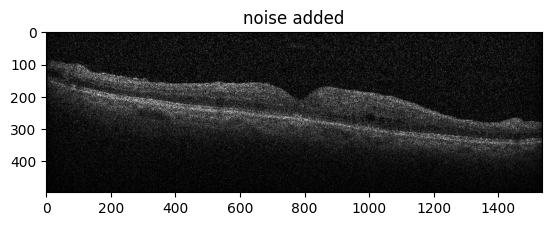

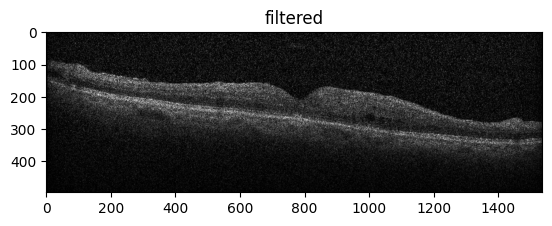

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


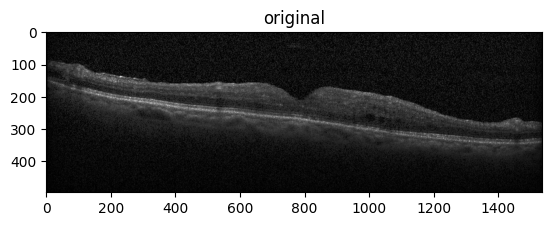

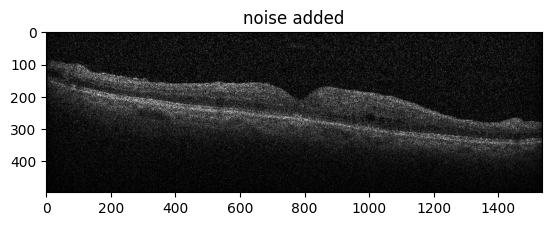

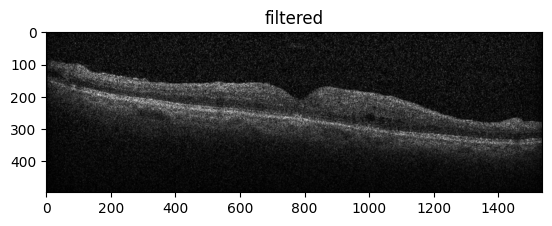

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


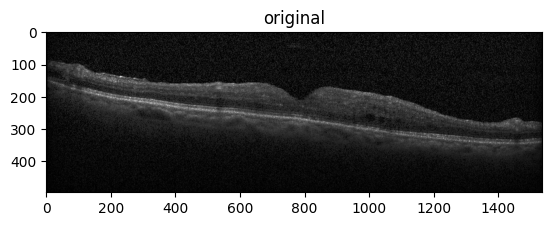

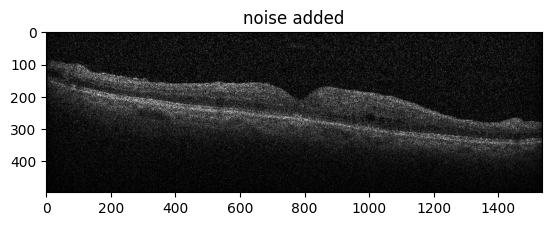

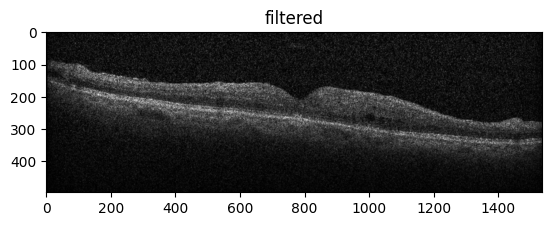

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


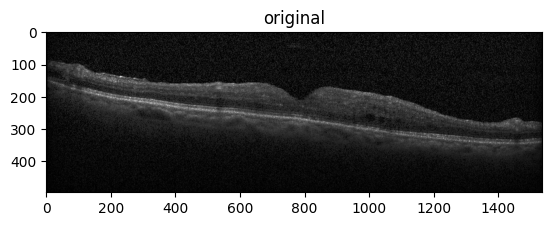

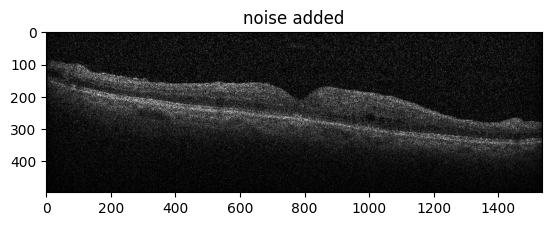

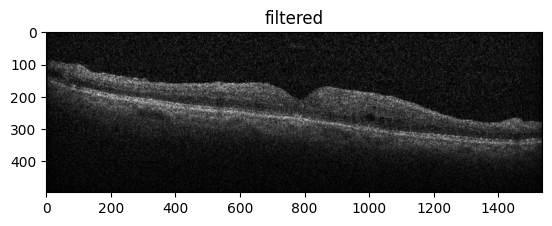

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


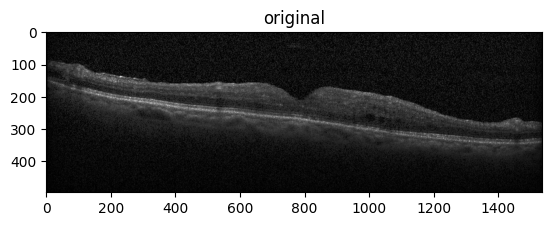

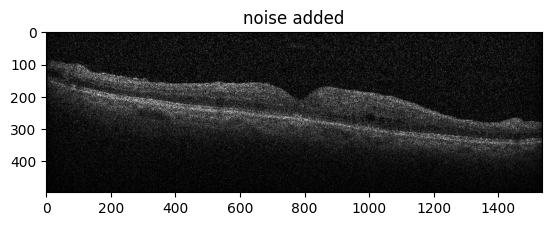

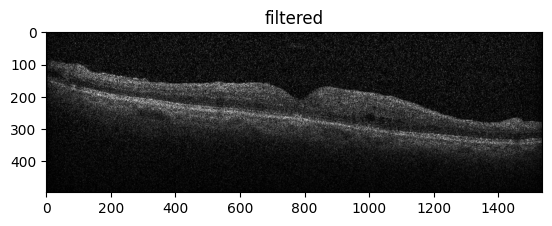

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


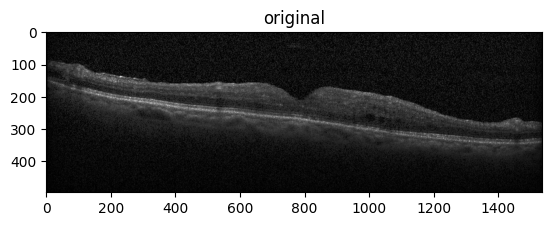

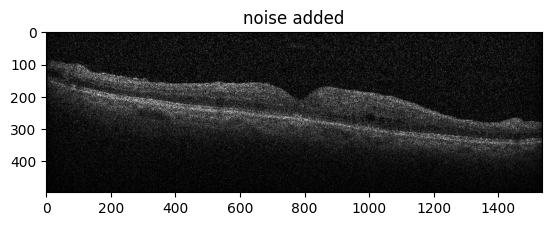

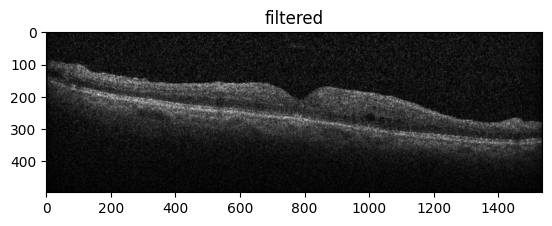

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


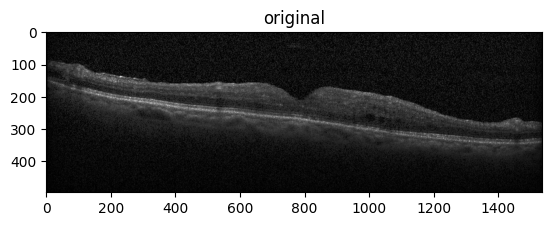

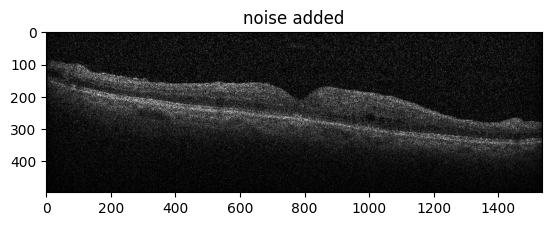

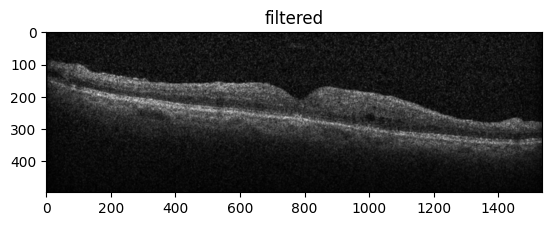

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


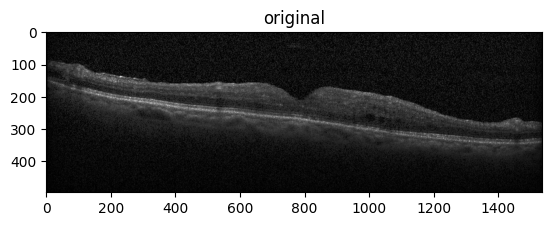

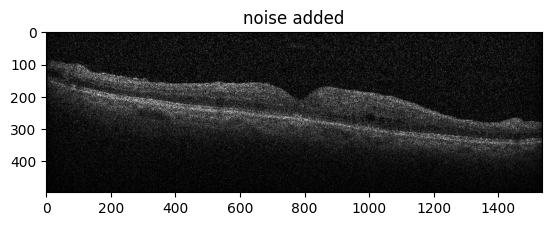

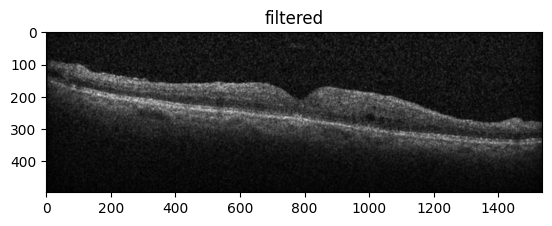

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


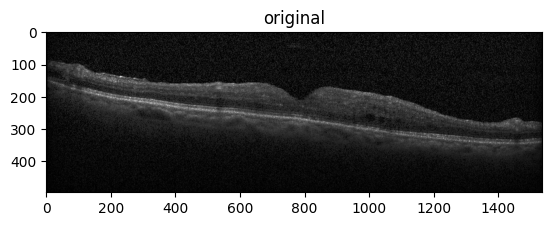

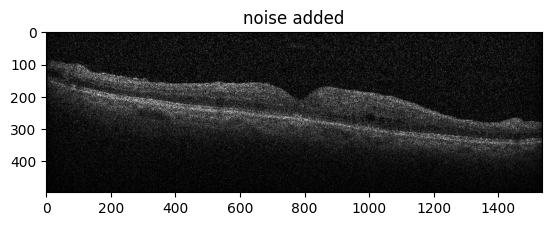

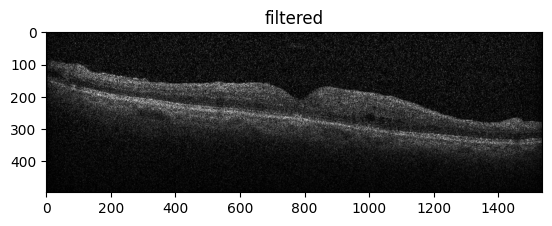

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


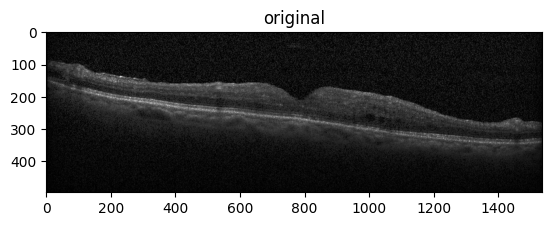

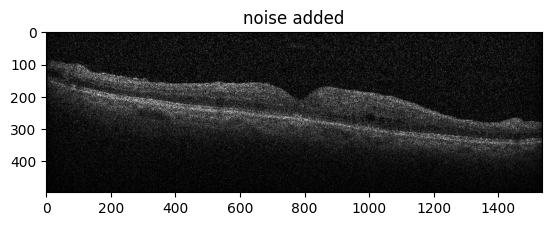

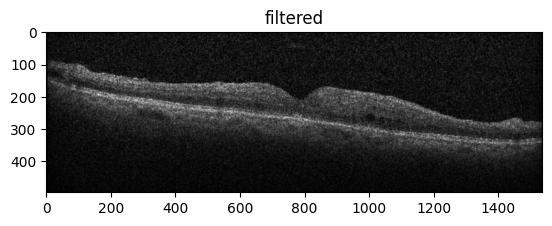

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


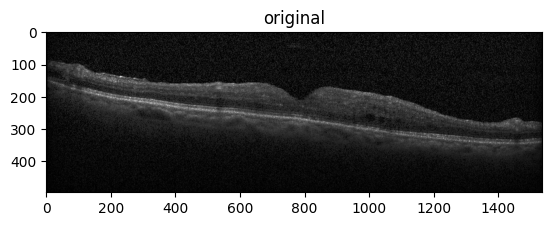

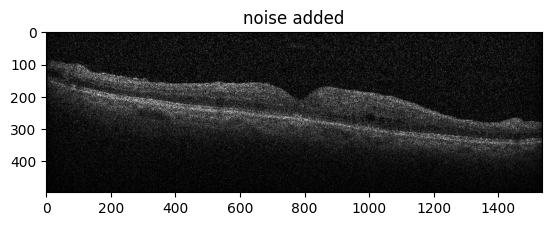

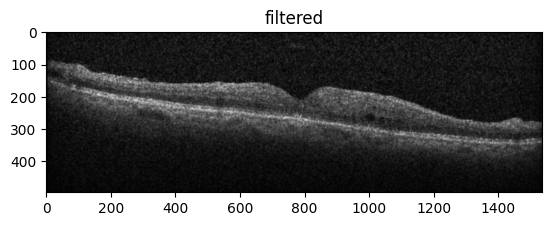

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


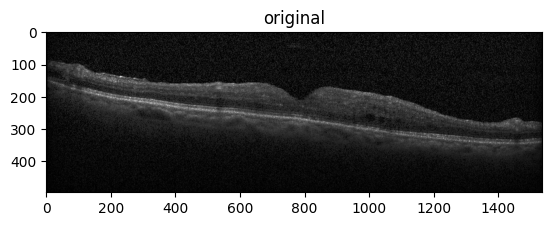

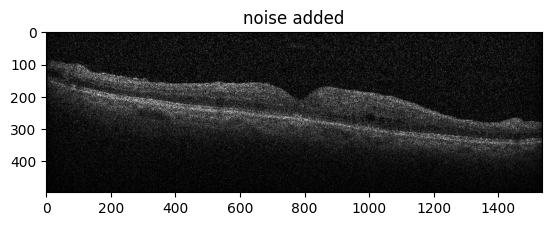

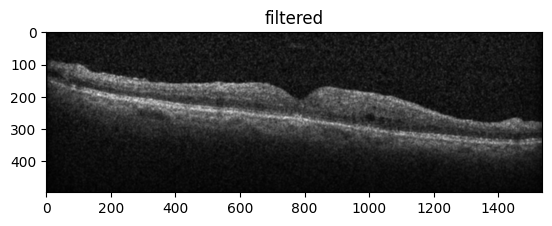

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


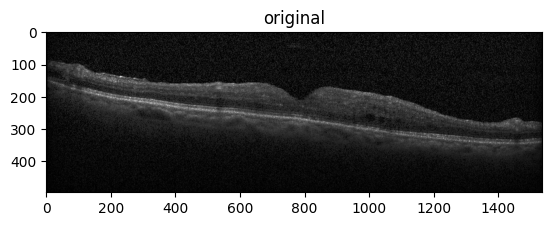

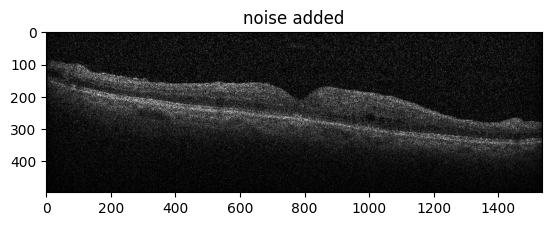

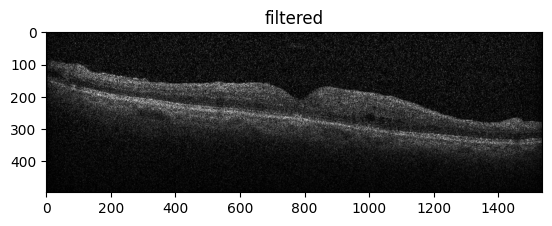

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


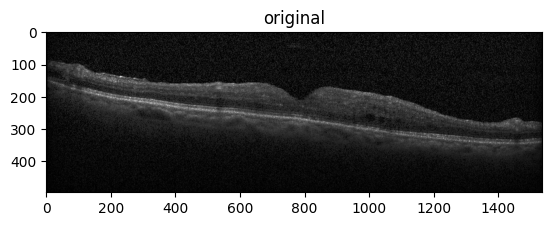

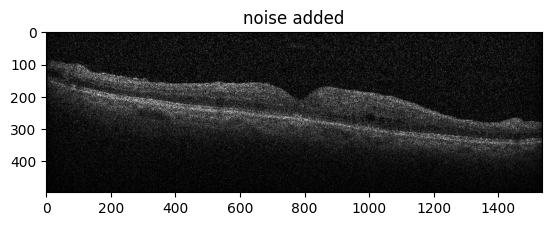

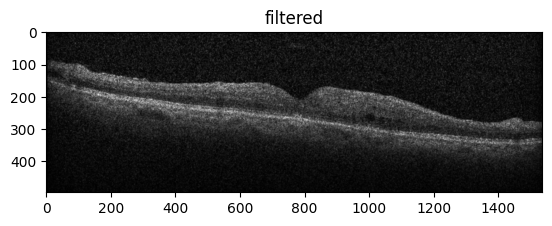

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


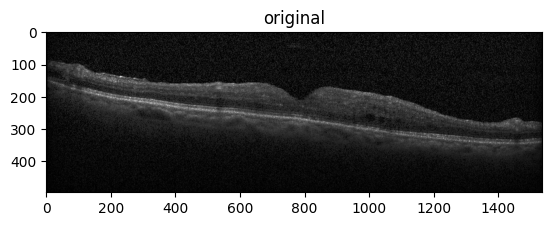

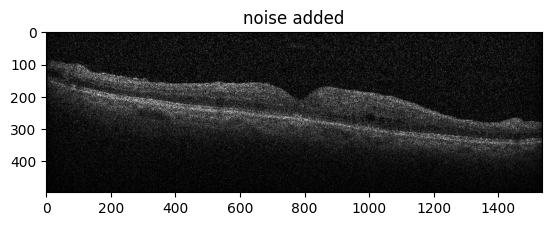

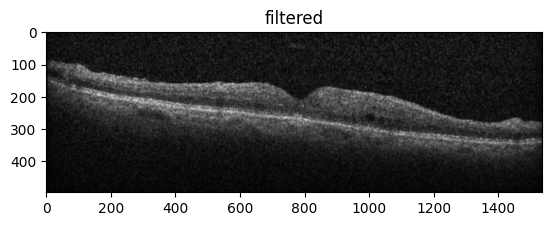

images speckle
(496, 1536)
float64
ogirinal images
(496, 1536)
float64
after Gaussian
(496, 1536)
float64


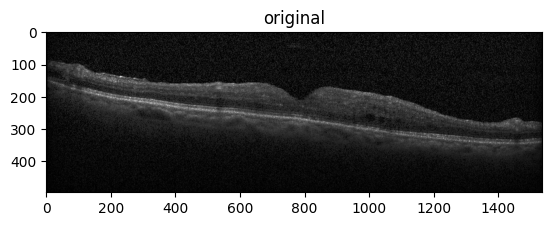

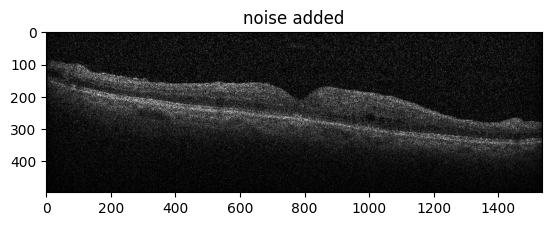

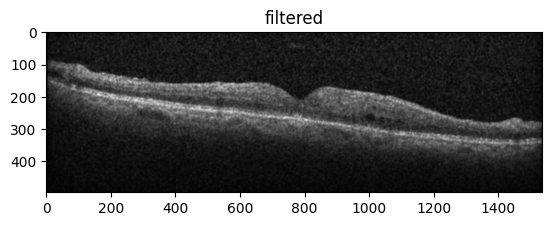

error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/median_blur.simd.hpp:887: error: (-210:Unsupported format or combination of formats)  in function 'medianBlur'


In [22]:
#sum of all the denoising techniques:4x4 +4+4 +8 +2
psnrs = np.zeros((34,3))
denoise_techniques = []


images = [Ker, ID, DL]
images_speckle = [Ker_speckle,ID_speckle,DL_speckle]
for i in range(len(images)):
  #Gaussian
  kernel_sizes = [3,5,7,9]
  sigmas = [0.5,1.0,1.5,2.0]

  count = 0
  for k in kernel_sizes:
    for s in sigmas:
      #print("kernel {} sigma {}".format(k,s))
      print("images speckle")
      print(images_speckle[i].shape)
      print(images_speckle[i].dtype)
      print("ogirinal images")
      print(images[i].shape)
      print(images[i].dtype)

      Gaus = cv2.GaussianBlur(images_speckle[i],(k,k),s)
      print("after Gaussian")
      print(Gaus.shape)
      print(Gaus.dtype)


      plt.imshow(images[i],cmap="gray")
      plt.title("original")
      plt.show()


      plt.imshow(images_speckle[i],cmap="gray")
      plt.title("noise added")
      plt.show()


      plt.imshow(Gaus,cmap="gray")
      plt.title("filtered")
      plt.show()


      psnr = cv2.PSNR(images[i], Gaus)

      #psnr_ski_ID = skimage.metrics.peak_signal_noise_ratio(ID, Gaus_ID)

      #print(psnr_ID)
      psnrs[count,i] = psnr
      count +=1
      if i==0:
        denoise_techniques.append("Gaussian {}x{} sigma {}".format(k,k,s))
  #Median
  kernel_sizes = [3,5,7,9]


  for k in kernel_sizes:
    med = cv2.medianBlur(images_speckle[i],k)
    psnr = cv2.PSNR(images[i],med)
    psnrs[count,i] = psnr
    count +=1

    if i ==0:
      denoise_techniques.append("Median {}x{}".format(k,k))
  #Mean
  kernel_sizes = [3,5,7,9]

  for k in kernel_sizes:
    mean = cv2.blur(images_speckle[i],(k,k))
    psnr = cv2.PSNR(images[i],mean)
    psnrs[count,i] = psnr
    count +=1

    if i ==0:
      denoise_techniques.append("Mean {}x{}".format(k,k))
  #Bilateral
  ds = [5,7]
  sigmas_color = [10,20]
  sigmas_space = [10,20]

  for d in ds:
    for sc in sigmas_color:
      for ss in sigmas_color:
        bilateral = cv2.bilateralFilter(images_speckle[i],d,sc,ss)
        psnr = cv2.PSNR(images[i],bilateral)
        psnrs[count,i] = psnr
        count+=1

        if i ==0:
          denoise_techniques.append("Bilateral d {} sigmaColor {} sigmaSpace{}".format(d,sc,ss))

  #Non local means
  hs = [10,20]

  for h in hs:
    nl =cv2.fastNlMeansDenoising(images_speckle[i],h) #search window and block size are default size? #should I vary them as well?
    psnr =cv2.PSNR(images[i],nl)
    psnrs[count,i] = psnr
    count+=1

    if i ==0:
      denoise_techniques.append("Non-local means h {}".format(h))



#print(psnrs)
#print(denoise_techniques)

# SSIM

In [ ]:
#SSIM is calculated with skimage rather than opencv because it seems it is more convenient to implement it in skimage
#sum of all the denoising techniques:4x4 +4+4 +8
ssims = np.zeros((32,3))
denoise_techniques = []


images = [Ker, ID, DL]
for i in range(len(images)):
  #Gaussian
  kernel_sizes = [3,5,7,9]
  sigmas = [0.5,1.0,1.5,2.0]

  count = 0
  for k in kernel_sizes:
    for s in sigmas:
      #print("kernel {} sigma {}".format(k,s))

      Gaus = cv2.GaussianBlur(images[i],(k,k),s)

      ssim = skimage.metrics.structural_similarity(images[i], Gaus)

      psnrs[count,i] = psnr
      count +=1
      if i==0:
        denoise_techniques.append("Gaussian {}x{} sigma {}".format(k,k,s))
  #Median
  kernel_sizes = [3,5,7,9]


  for k in kernel_sizes:
    med = cv2.medianBlur(images[i],k)
    psnr = cv2.PSNR(images[i],med)
    psnrs[count,i] = psnr
    count +=1

    if i ==0:
      denoise_techniques.append("Median {}x{}".format(k,k))
  #Mean
  kernel_sizes = [3,5,7,9]

  for k in kernel_sizes:
    mean = cv2.blur(images[i],(k,k))
    psnr = cv2.PSNR(images[i],mean)
    psnrs[count,i] = psnr
    count +=1

    if i ==0:
      denoise_techniques.append("Mean {}x{}".format(k,k))
  #Bilateral
  ds = [5,7]
  sigmas_color = [10,20]
  sigmas_space = [10,20]

  for d in ds:
    for sc in sigmas_color:
      for ss in sigmas_color:
        bilateral = cv2.bilateralFilter(images[i],d,sc,ss)
        psnr = cv2.PSNR(images[i],bilateral)
        psnrs[count,i] = psnr
        count+=1

        if i ==0:
          denoise_techniques.append("Bilateral d {} sigmaColor {} sigmaSpace{}".format(d,sc,ss))
#print(psnrs)
#print(denoise_techniques)